# 03 — PADS Integration: Add Healthy Controls

**Phase 2** — Run this only after PADS finishes downloading.

Objective: Add PADS Healthy Control subjects as the negative class (PD=0) to ALAMEDA's PD-positive data, then retrain the binary PD vs. Healthy classifier.

In [9]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 8.5 MB/s eta 0:00:12
    --------------------------------------- 2.1/101.7 MB 7.3 MB/s eta 0:00:14
   - -------------------------------------- 4.2/101.7 MB 9.0 MB/s eta 0:00:11
   -- ------------------------------------- 7.1/101.7 MB 10.4 MB/s eta 0:00:10
   ---- ----------------------------------- 10.5/101.7 MB 11.9 MB/s eta 0:00:08
   ------ --------------------------------- 15.7/101.7 MB 14.3 MB/s eta 0:00:06
   -------- ------------------------------- 20.7/101.7 MB 16.0 MB/s eta 0:00:06
   --------- ------------------------------ 25.2/101.7 MB 16.8 MB/s eta 0:00:05
   ------------ --------------------------- 31.7/101.7 MB 18.6 MB/s eta 0:00:04
   -------------- ------------------------- 37.5/101.7 MB 19.7 MB/s eta 0:00:04
   ---------------- ----------------------- 41.9/101.7 MB 19.9 MB/s eta 0:00:04
   ------------------ --------------------- 46.9/101.7 M


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style='darkgrid')
warnings.filterwarnings('ignore')
print('Imports OK ✓')

Imports OK ✓


In [19]:
df = pd.read_csv('../data/ALAMEDA_PD_tremor_dataset.csv')

META   = ['start_timestamp', 'end_timestamp', 'subject_id']
LABELS = ['Rest_tremor', 'Postural_tremor', 'Kinetic_tremor', 'Constancy_of_rest']
TARGET = 'Rest_tremor'

META_JOINED = META + LABELS
ORIGINAL_FEATURES = [c for c in df.columns if c not in META_JOINED]

print(f'Original features : {len(ORIGINAL_FEATURES)}')
print(f'Windows           : {len(df)}')
print(f'Subjects          : {df["subject_id"].nunique()}')
print(f'Class balance     : {df[TARGET].value_counts().to_dict()}')

# Sanity check key columns
required = [
    'Magnitude_fft_pw_ar_dom_freq', 'Magnitude_fft_tot_power',
    'Magnitude_fft_dom_freq', 'PC1_fft_dom_freq',
    'PC1_fft_pw_ar_dom_freq', 'PC1_fft_tot_power',
    'Magnitude_sampen', 'Magnitude_dfa', 'PC1_sampen', 'PC1_dfa',
    'PC1_zero_cross_rt', 'PC1_peaks_rt',
]
missing = [c for c in required if c not in df.columns]
print(f'\nMissing columns: {missing}' if missing else '\nAll required columns present ✓')

Original features : 92
Windows           : 4151
Subjects          : 11
Class balance     : {0: 2576, 1: 1575}

All required columns present ✓


In [20]:
fe = df.copy()

# 2a. Tremor Band Dominance (4–6 Hz)
fe['tremor_band_flag']     = ((fe['Magnitude_fft_dom_freq'] >= 4.0) & (fe['Magnitude_fft_dom_freq'] <= 6.0)).astype(int)
fe['tremor_band_dist']     = np.abs(fe['Magnitude_fft_dom_freq'] - 5.0)
fe['PC1_tremor_band_flag'] = ((fe['PC1_fft_dom_freq'] >= 4.0) & (fe['PC1_fft_dom_freq'] <= 6.0)).astype(int)
fe['PC1_tremor_band_dist'] = np.abs(fe['PC1_fft_dom_freq'] - 5.0)

# 2b. Tremor Power Ratio  ← THE FIX: pw_ar not pwar
fe['tremor_power_ratio']     = fe['Magnitude_fft_pw_ar_dom_freq'] / (fe['Magnitude_fft_tot_power'] + 1e-10)
fe['PC1_tremor_power_ratio'] = fe['PC1_fft_pw_ar_dom_freq']       / (fe['PC1_fft_tot_power']       + 1e-10)

# 2c. Signal Regularity Ratio
fe['regularity_ratio_Magnitude'] = fe['Magnitude_sampen'] / (fe['Magnitude_dfa'] + 1e-10)
fe['regularity_ratio_PC1']       = fe['PC1_sampen']       / (fe['PC1_dfa']       + 1e-10)

# 2d. Jerk Proxy
fe['jerk_ratio']     = fe['Magnitude_avg_diff_mean'] / (fe['Magnitude_std_dev'] + 1e-10)
fe['PC1_jerk_ratio'] = fe['PC1_avg_diff_mean']       / (fe['PC1_std_dev']       + 1e-10)

# 2e. Axis Dominance
fe['axis_dominance']     = fe['PC1_std_dev']     / (fe['Magnitude_std_dev']     + 1e-10)
fe['axis_dominance_fft'] = fe['PC1_fft_std_dev'] / (fe['Magnitude_fft_std_dev'] + 1e-10)

# 2f. Spectral Entropy & Flatness Ratios
fe['spectral_entropy_ratio']  = fe['Magnitude_fft_entropy']  / (fe['PC1_fft_entropy']  + 1e-10)
fe['spectral_flatness_ratio'] = fe['Magnitude_fft_flatness'] / (fe['PC1_fft_flatness'] + 1e-10)

# 2g. Zero-Cross × Peaks Interaction
fe['zcr_peak_interaction'] = fe['PC1_zero_cross_rt'] * fe['PC1_peaks_rt']

ENGINEERED = [
    'tremor_band_flag', 'tremor_band_dist',
    'PC1_tremor_band_flag', 'PC1_tremor_band_dist',
    'tremor_power_ratio', 'PC1_tremor_power_ratio',
    'regularity_ratio_Magnitude', 'regularity_ratio_PC1',
    'jerk_ratio', 'PC1_jerk_ratio',
    'axis_dominance', 'axis_dominance_fft',
    'spectral_entropy_ratio', 'spectral_flatness_ratio',
    'zcr_peak_interaction',
]
ALL_FEATURES = ORIGINAL_FEATURES + ENGINEERED

print(f'Engineered : {len(ENGINEERED)} | Total : {len(ALL_FEATURES)}')
nan_counts = fe[ALL_FEATURES].isna().sum()
print('NaN found:\n', nan_counts[nan_counts > 0]) if nan_counts.any() else print('No NaN ✓')

Engineered : 15 | Total : 107
No NaN ✓


In [21]:
print("\\n=== XGBoost Per-Subject Results ===")
print(res_xgb[["subject", "balanced_accuracy", "roc_auc", "n_test", "n_positive"]].to_string(index=False))

\n=== XGBoost Per-Subject Results ===


NameError: name 'res_xgb' is not defined

In [22]:
X_orig = fe[ORIGINAL_FEATURES].values
X_all  = fe[ALL_FEATURES].values
y      = fe[TARGET].values
groups = fe['subject_id'].values
subjects = np.unique(groups)

def loso_cv(X, y, groups, clf_factory, label='Model', use_smote=True):
    results = []
    for test_subject in np.unique(groups):
        train_mask = groups != test_subject
        test_mask  = groups == test_subject

        X_train, y_train = X[train_mask], y[train_mask]
        X_test,  y_test  = X[test_mask],  y[test_mask]

        if use_smote:
            try:
                X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)
            except ValueError:
                pass

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        clf = clf_factory()
        clf.fit(X_train_sc, y_train)

        y_pred = clf.predict(X_test_sc)
        y_prob = clf.predict_proba(X_test_sc)[:, 1]

        bal_acc = balanced_accuracy_score(y_test, y_pred)
        try:
            auc = roc_auc_score(y_test, y_prob)
        except ValueError:
            auc = float('nan')

        results.append({
            'subject':           test_subject,
            'balanced_accuracy': bal_acc,
            'roc_auc':           auc,
            'n_test':            len(y_test),
            'n_positive':        y_test.sum(),
            'model':             label,
        })
    return pd.DataFrame(results)

print('LOSO helper defined ✓')

LOSO helper defined ✓


In [23]:
rf_factory = lambda: RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1
)

neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {spw:.2f}  (neg={neg_count}, pos={pos_count})')

xgb_factory = lambda: XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)

print('\n[1/3] RF — Original features ...')
res_rf_orig = loso_cv(X_orig, y, groups, rf_factory,
                      label=f'RF ({len(ORIGINAL_FEATURES)} features)')

print('[2/3] RF — Original + Engineered features ...')
res_rf_all  = loso_cv(X_all,  y, groups, rf_factory,
                      label=f'RF ({len(ALL_FEATURES)} features)')

print('[3/3] XGBoost — Original + Engineered (no SMOTE) ...')
res_xgb     = loso_cv(X_all,  y, groups, xgb_factory,
                      label=f'XGB ({len(ALL_FEATURES)} features)', use_smote=False)

all_results = pd.concat([res_rf_orig, res_rf_all, res_xgb], ignore_index=True)

model_order = [
    f'RF ({len(ORIGINAL_FEATURES)} features)',
    f'RF ({len(ALL_FEATURES)} features)',
    f'XGB ({len(ALL_FEATURES)} features)',
]

print('\n' + '='*62)
print(f'{"Model":<35} {"Bal.Acc":>10} {"AUC":>10}')
print('='*62)
for label in model_order:
    grp = all_results[all_results['model'] == label]
    print(f'{label:<35} '
          f'{grp["balanced_accuracy"].mean():.3f}±{grp["balanced_accuracy"].std():.3f}   '
          f'{grp["roc_auc"].mean():.3f}±{grp["roc_auc"].std():.3f}')

scale_pos_weight = 1.64  (neg=2576, pos=1575)

[1/3] RF — Original features ...
[2/3] RF — Original + Engineered features ...
[3/3] XGBoost — Original + Engineered (no SMOTE) ...

Model                                  Bal.Acc        AUC
RF (92 features)                    0.508±0.184   0.461±0.075
RF (107 features)                   0.505±0.192   0.433±0.073
XGB (107 features)                  0.457±0.172   0.429±0.003


In [31]:
    # Redefine target
TARGET = 'Constancy_of_rest'

y      = fe[TARGET].values
groups = fe['subject_id'].values

neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
spw = neg_count / pos_count

print(f'Class balance: neg={neg_count}, pos={pos_count}')
print(f'scale_pos_weight = {spw:.2f}')
print(f'\nPer-subject positive windows:')
print(fe.groupby("subject_id")[TARGET].sum())

Class balance: neg=1001, pos=3150
scale_pos_weight = 0.32

Per-subject positive windows:
subject_id
2     175
4     700
7     175
8     175
9     350
11    350
12      0
13      0
14    350
15    175
16    700
Name: Constancy_of_rest, dtype: int64


In [32]:
rf_factory = lambda: RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1
)

neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {spw:.2f}  (neg={neg_count}, pos={pos_count})')

xgb_factory = lambda: XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)

print('\n[1/3] RF — Original features ...')
res_rf_orig = loso_cv(X_orig, y, groups, rf_factory,
                      label=f'RF ({len(ORIGINAL_FEATURES)} features)')

print('[2/3] RF — Original + Engineered features ...')
res_rf_all  = loso_cv(X_all,  y, groups, rf_factory,
                      label=f'RF ({len(ALL_FEATURES)} features)')

print('[3/3] XGBoost — Original + Engineered (no SMOTE) ...')
res_xgb     = loso_cv(X_all,  y, groups, xgb_factory,
                      label=f'XGB ({len(ALL_FEATURES)} features)', use_smote=False)

all_results = pd.concat([res_rf_orig, res_rf_all, res_xgb], ignore_index=True)

model_order = [
    f'RF ({len(ORIGINAL_FEATURES)} features)',
    f'RF ({len(ALL_FEATURES)} features)',
    f'XGB ({len(ALL_FEATURES)} features)',
]

print('\n' + '='*62)
print(f'{"Model":<35} {"Bal.Acc":>10} {"AUC":>10}')
print('='*62)
for label in model_order:
    grp = all_results[all_results['model'] == label]
    print(f'{label:<35} '
          f'{grp["balanced_accuracy"].mean():.3f}±{grp["balanced_accuracy"].std():.3f}   '
          f'{grp["roc_auc"].mean():.3f}±{grp["roc_auc"].std():.3f}')

scale_pos_weight = 0.32  (neg=1001, pos=3150)

[1/3] RF — Original features ...
[2/3] RF — Original + Engineered features ...
[3/3] XGBoost — Original + Engineered (no SMOTE) ...

Model                                  Bal.Acc        AUC
RF (92 features)                    0.551±0.289   0.384±0.099
RF (107 features)                   0.559±0.308   0.374±0.100
XGB (107 features)                  0.528±0.264   0.371±0.101


In [33]:
print('=== XGBoost Per-Subject Results ===')
print(res_xgb[['subject', 'balanced_accuracy', 'roc_auc',
               'n_test', 'n_positive']].to_string(index=False))

=== XGBoost Per-Subject Results ===
 subject  balanced_accuracy  roc_auc  n_test  n_positive
       2           0.400000 0.342204     350         175
       4           0.490000 0.482339    1050         700
       7           0.565714      NaN     175         175
       8           0.754286      NaN     175         175
       9           0.611429      NaN     350         350
      11           0.452857 0.287211     392         350
      12           0.095238      NaN      84           0
      13           0.065714      NaN     350           0
      14           0.842857      NaN     350         350
      15           0.760000      NaN     175         175
      16           0.772857      NaN     700         700


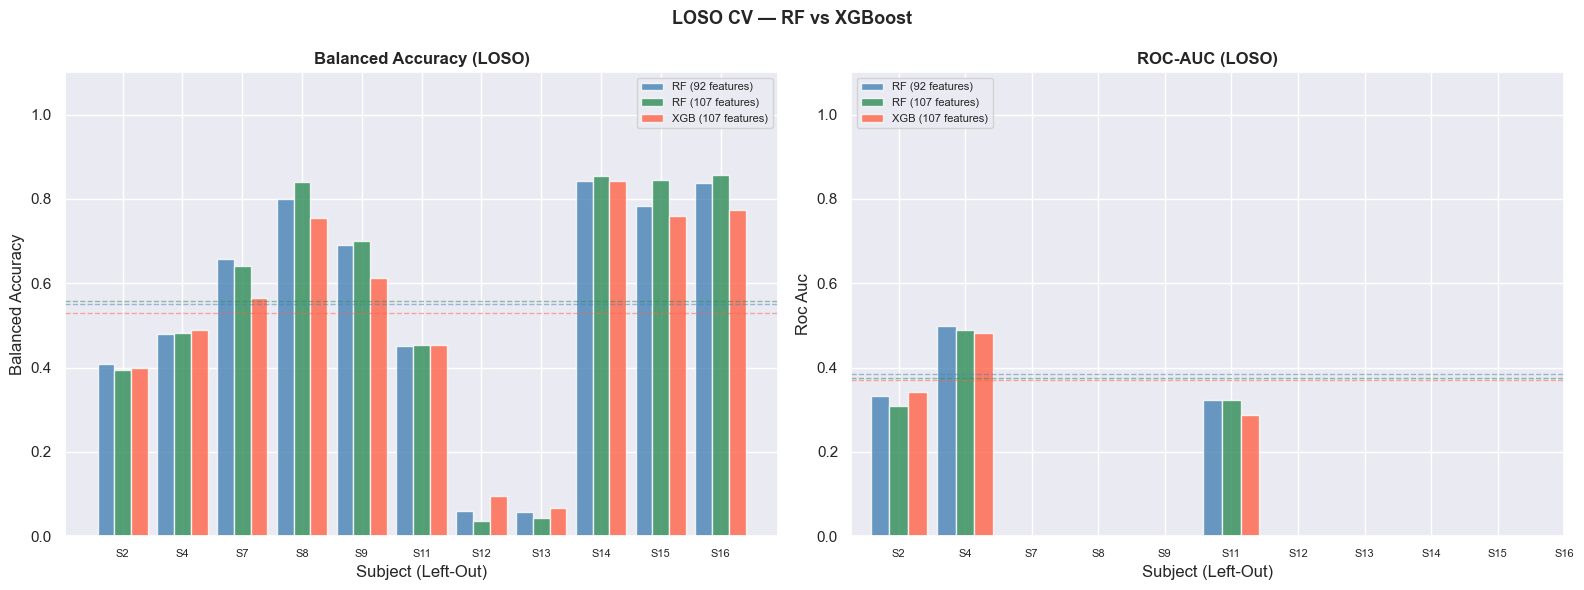

In [34]:
import os
os.makedirs('../models', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['steelblue', 'seagreen', 'tomato']
x = np.arange(len(subjects))
width = 0.28

for ax, metric, title in zip(
    axes,
    ['balanced_accuracy', 'roc_auc'],
    ['Balanced Accuracy (LOSO)', 'ROC-AUC (LOSO)'],
):
    for i, (label, color) in enumerate(zip(model_order, colors)):
        grp = all_results[all_results['model'] == label].sort_values('subject')
        ax.bar(x + (i - 1) * width, grp[metric], width,
               label=label, color=color, alpha=0.8)
    for label, color in zip(model_order, colors):
        mean = all_results[all_results['model'] == label][metric].mean()
        ax.axhline(mean, linestyle='--', color=color, alpha=0.5, linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels([f'S{s}' for s in sorted(subjects)], fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('Subject (Left-Out)')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('LOSO CV — RF vs XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/model_comparison_03.png', dpi=120)
plt.show()

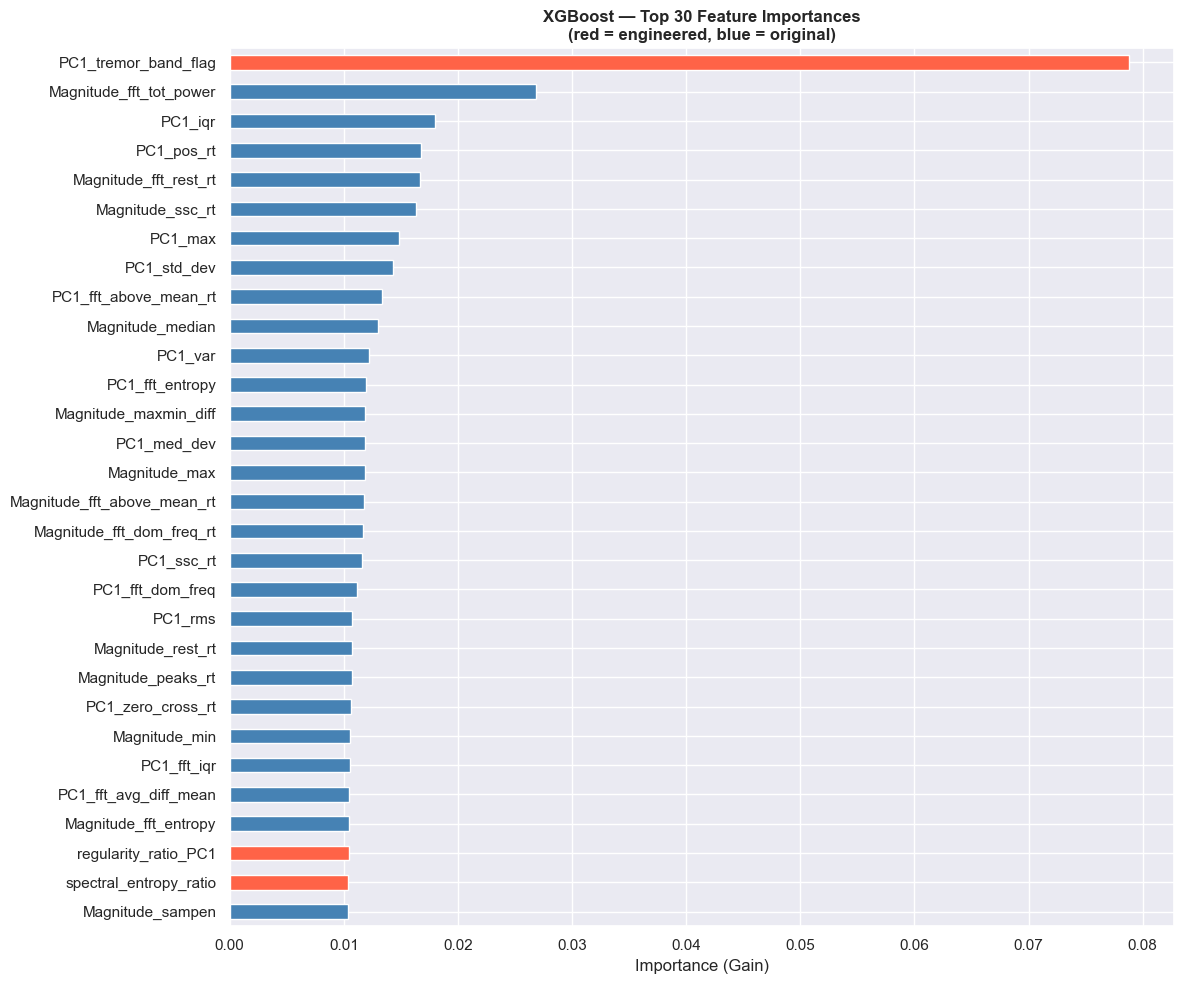

Engineered in Top 30: 3/15

Top 10:
   1. ★ ENG PC1_tremor_band_flag                          0.0788
   2.       Magnitude_fft_tot_power                       0.0268
   3.       PC1_iqr                                       0.0180
   4.       PC1_pos_rt                                    0.0168
   5.       Magnitude_fft_rest_rt                         0.0167
   6.       Magnitude_ssc_rt                              0.0163
   7.       PC1_max                                       0.0148
   8.       PC1_std_dev                                   0.0143
   9.       PC1_fft_above_mean_rt                         0.0133
  10.       Magnitude_median                              0.0130


In [35]:
X_res, y_res = SMOTE(random_state=42).fit_resample(X_all, y)
scaler_final = StandardScaler()
X_sc = scaler_final.fit_transform(X_res)

xgb_final = xgb_factory()
xgb_final.fit(X_sc, y_res)

feat_imp = pd.Series(
    xgb_final.feature_importances_, index=ALL_FEATURES
).sort_values(ascending=False)

top30 = feat_imp.head(30)
engineered_mask = [f in ENGINEERED for f in top30.index]

fig, ax = plt.subplots(figsize=(12, 10))
colors_imp = ['tomato' if e else 'steelblue' for e in engineered_mask]
top30.sort_values().plot(kind='barh', ax=ax, color=list(reversed(colors_imp)))
ax.set_title('XGBoost — Top 30 Feature Importances\n(red = engineered, blue = original)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance (Gain)')
plt.tight_layout()
plt.savefig('../models/xgb_feature_importance_03.png', dpi=120)
plt.show()

print(f'Engineered in Top 30: {sum(engineered_mask)}/{len(ENGINEERED)}')
print('\nTop 10:')
for i, (feat, imp) in enumerate(feat_imp.head(10).items(), 1):
    marker = '★ ENG' if feat in ENGINEERED else '     '
    print(f'  {i:2}. {marker} {feat:<45} {imp:.4f}')

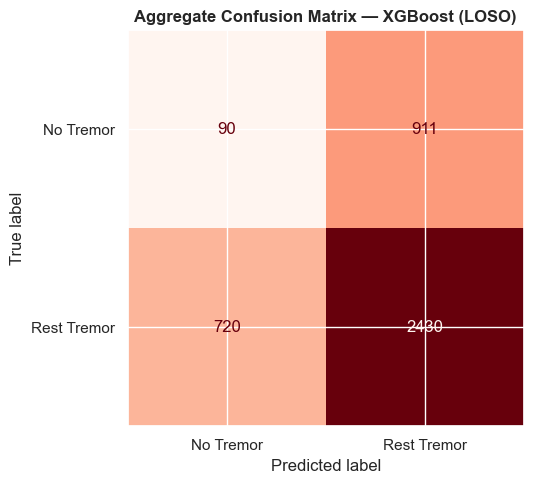

              precision    recall  f1-score   support

   No Tremor       0.11      0.09      0.10      1001
 Rest Tremor       0.73      0.77      0.75      3150

    accuracy                           0.61      4151
   macro avg       0.42      0.43      0.42      4151
weighted avg       0.58      0.61      0.59      4151



In [36]:
all_y_true, all_y_pred = [], []

for test_subject in subjects:
    train_mask = groups != test_subject
    test_mask  = groups == test_subject

    X_train, y_train = X_all[train_mask], y[train_mask]
    X_test,  y_test  = X_all[test_mask],  y[test_mask]

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    clf = xgb_factory()
    clf.fit(X_train_sc, y_train)
    all_y_true.extend(y_test)
    all_y_pred.extend(clf.predict(X_test_sc))

cm = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Tremor', 'Rest Tremor'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Aggregate Confusion Matrix — XGBoost (LOSO)', fontweight='bold')
plt.tight_layout()
plt.savefig('../models/xgb_confusion_matrix_03.png', dpi=120)
plt.show()

print(classification_report(all_y_true, all_y_pred,
                            target_names=['No Tremor', 'Rest Tremor']))

In [37]:
model_bundle = {
    'model':               xgb_final,
    'scaler':              scaler_final,
    'original_features':   ORIGINAL_FEATURES,
    'engineered_features': ENGINEERED,
    'all_features':        ALL_FEATURES,
    'target':              TARGET,
    'notes': {
        'validation':       'LOSO CV',
        'class_balance':    f'neg={neg_count}, pos={pos_count}',
        'scale_pos_weight': spw,
    }
}

with open('../models/xgb_model_03.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('Model saved → ../models/xgb_model_03.pkl ✓')
print(f'{len(ORIGINAL_FEATURES)} original + {len(ENGINEERED)} engineered = {len(ALL_FEATURES)} total')

Model saved → ../models/xgb_model_03.pkl ✓
92 original + 15 engineered = 107 total


In [38]:
print(df[LABELS].sum())
print('\nPer-subject positive counts:')
for label in LABELS:
    print(f'\n{label}:')
    print(df.groupby('subject_id')[label].sum())

Rest_tremor          1575
Postural_tremor       875
Kinetic_tremor        175
Constancy_of_rest    3150
dtype: int64

Per-subject positive counts:

Rest_tremor:
subject_id
2       0
4     175
7       0
8       0
9     350
11      0
12      0
13      0
14    175
15    175
16    700
Name: Rest_tremor, dtype: int64

Postural_tremor:
subject_id
2       0
4     525
7     175
8       0
9       0
11      0
12      0
13      0
14      0
15    175
16      0
Name: Postural_tremor, dtype: int64

Kinetic_tremor:
subject_id
2       0
4     175
7       0
8       0
9       0
11      0
12      0
13      0
14      0
15      0
16      0
Name: Kinetic_tremor, dtype: int64

Constancy_of_rest:
subject_id
2     175
4     700
7     175
8     175
9     350
11    350
12      0
13      0
14    350
15    175
16    700
Name: Constancy_of_rest, dtype: int64
